# 05. Product calibration and empirical action support

This notebook converts the pooled behavioral calibration into product-specific parameter distributions and constructs the promotion-depth action sets used by the optimizer.

Product-level estimates are partially pooled toward the category calibration when product-specific promotion information is limited. The resulting draws preserve uncertainty in contemporaneous lift, displacement strength, and persistence. Draw weights are normalized within product and are used to average schedule values in the policy analysis.

Promotion depths are restricted using empirical action support. Positive discounts are grouped into five-percentage-point bins, and a bin is retained only when it meets the pre-specified observation and panel-count thresholds. This restriction limits functional-form extrapolation but does not establish causal overlap or guarantee that every supported action is operationally feasible.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dynamic_promotion_planning.action_support import (
    SupportedActionConfig,
    build_product_supported_action_sets,
)
from dynamic_promotion_planning.calibration import (
    CalibrationConfig,
    calibrate_products,
    load_clean_history,
)
from dynamic_promotion_planning.config import load_analysis_config
from dynamic_promotion_planning.paths import project_paths

# Resolve repository paths and load the centralized analysis specification.
paths = project_paths()
analysis_config = load_analysis_config()

PROJECT_ROOT = paths.root
PROCESSED_DIR = paths.data_processed
DEMAND_ARTIFACT_DIR = paths.artifact_demand
CALIBRATION_ARTIFACT_DIR = paths.artifact_calibration
TABLE_DIR = paths.result_tables
FIGURE_DIR = paths.result_figures

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0


In [2]:
# Canonical inputs produced by earlier notebooks.
DATA_PATH = PROCESSED_DIR / "cereal_demand_model_data.parquet"
PREDICTION_PATH = DEMAND_ARTIFACT_DIR / "demand_predictions.pkl"
POOLED_DRAW_PATH = CALIBRATION_ARTIFACT_DIR / "pooled_behavioral_draws.pkl"

# Product-calibration artifacts consumed by later policy notebooks.
PRODUCT_DRAW_PATH = CALIBRATION_ARTIFACT_DIR / "product_behavioral_draws.pkl"
PRODUCT_BASE_PATH = CALIBRATION_ARTIFACT_DIR / "product_behavioral_bootstrap.pkl"
PRODUCT_CALIBRATION_ARTIFACT_PATH = (
    CALIBRATION_ARTIFACT_DIR / "product_calibration.pkl"
)
PRODUCT_ACTION_SET_PATH = CALIBRATION_ARTIFACT_DIR / "supported_actions.pkl"

# Tables exported for diagnostics and reporting.
PRODUCT_SUMMARY_PATH = TABLE_DIR / "product_calibration_summary.csv"
PRODUCT_EVENT_PATH = TABLE_DIR / "product_promotion_event_study.csv"
PRODUCT_HOLDOUT_PATH = TABLE_DIR / "product_holdout_event_validation.csv"
PRODUCT_HOLDOUT_SUMMARY_PATH = (
    TABLE_DIR / "product_holdout_validation_summary.csv"
)
PRODUCT_ACTION_SUPPORT_PATH = TABLE_DIR / "supported_action_clusters.csv"

# Figure outputs. These variables were previously used later without definition.
HOLDOUT_FIGURE_PATH = FIGURE_DIR / "product_holdout_validation.png"
ACTION_FIGURE_PATH = FIGURE_DIR / "supported_promotion_actions.png"

# Create output directories before exporting artifacts.
CALIBRATION_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Convert the centralized configuration values into the typed objects expected
# by the product-calibration and empirical-support routines.
calibration_config = CalibrationConfig(
    primary_model=analysis_config.behavioral.primary_model,
    max_products=analysis_config.demand.n_products,
    bootstrap_replications=analysis_config.behavioral.bootstrap_replications,
    random_seed=analysis_config.behavioral.random_seed,
    event_window=tuple(range(-analysis_config.behavioral.event_pre_weeks, analysis_config.behavioral.event_post_weeks + 1)),
    holdout_window=tuple(range(-analysis_config.behavioral.holdout_pre_weeks, analysis_config.behavioral.holdout_post_weeks + 1)),
    pre_event_weeks=analysis_config.behavioral.pre_event_weeks,
    post_lags=analysis_config.behavioral.post_lags_for_calibration,
    min_isolated_events=analysis_config.behavioral.minimum_isolated_events,
    min_depth_events=analysis_config.behavioral.minimum_depth_events,
    min_common_panels=analysis_config.behavioral.minimum_common_panels,
    min_calibration_discount=analysis_config.behavioral.minimum_calibration_discount,
    shrinkage_event_scale=analysis_config.behavioral.shrinkage_event_scale,
    shrinkage_panel_scale=analysis_config.behavioral.shrinkage_panel_scale,
    persistence_grid=analysis_config.behavioral.persistence_partial_identification_grid,
    min_persistence_signal=analysis_config.behavioral.minimum_persistence_signal,
    max_persistence_slope_ratio=analysis_config.behavioral.maximum_persistence_slope_ratio,
)

support_design = analysis_config.support
support_config = SupportedActionConfig(
    bin_width=support_design.bin_width,
    minimum_depth=support_design.minimum_depth,
    maximum_depth=support_design.maximum_depth,
    minimum_observations=support_design.minimum_observations,
    minimum_panels=support_design.minimum_panels,
    maximum_positive_actions=support_design.maximum_positive_actions,
)

## 2. Product-level calibration

Product-specific calibration balances within-product information with the pooled category estimate. The displayed summaries describe the calibrated parameter distribution and its holdout performance. They are not confidence intervals for structural demand parameters.

In [4]:
# Product calibration depends on the pooled behavioral distribution estimated
# in the preceding notebook.
if not POOLED_DRAW_PATH.is_file():
    raise FileNotFoundError(
        "Run the pooled stockpiling calibration first."
    )

# Load the cleaned history, recursive demand predictions, selected products,
# product labels, and the calibration/evaluation split.
loaded = load_clean_history(
    data_path=DATA_PATH,
    prediction_path=PREDICTION_PATH,
    config=calibration_config,
)

history = loaded["history"]
selected_products = loaded["selected_products"]
product_names = loaded["product_names"]

if history.empty:
    raise RuntimeError("The cleaned calibration history is empty.")

if not selected_products:
    raise RuntimeError("No products were selected for product-level calibration.")

# Read the pooled draws that provide the partial-pooling reference distribution.
pooled_draws = pd.read_pickle(POOLED_DRAW_PATH)
if pooled_draws.empty:
    raise RuntimeError("The pooled behavioral-draw artifact is empty.")

# Estimate product-specific behavioral distributions using the frozen design.
calibration = calibrate_products(
    history=history,
    selected_products=selected_products,
    product_names=product_names,
    pooled_draws=pooled_draws,
    config=calibration_config,
)

product_draws = calibration["product_draws"]
product_base_draws = calibration["product_base_draws"]
product_summary = calibration["product_summary"]

In [5]:
# Extract event-study and temporal-holdout diagnostics returned by calibration.
product_event_study = calibration["product_event_study"]
product_holdout = calibration["product_holdout"]
product_holdout_summary = calibration["product_holdout_summary"]

if product_draws.empty:
    raise RuntimeError("Product calibration returned no behavioral draws.")

# Inspect calibrated parameter summaries and holdout validation statistics.
display(product_summary)
display(product_holdout_summary)

,upc,product_name,calibration_rows,evaluation_rows,panels,isolated_events,depth_events,common_panels,selected_gap,calibration_discount,shrinkage_reliability,price_elasticity_median,promotion_lift_median,displacement_median,persistence_median,persistence_informative_share,base_demand,regular_price,unit_cost
0,1600066610,1600066610,22636,5514,83,398,201,79,3/3,0.05,0.808709,0.734132,-0.047247,0.045061,0.35000,0.113462,37.0,3.22,2.662075
1,1600066590,1600066590,22522,5505,83,483,335,83,3/3,0.05,0.855934,0.673647,-0.009108,0.248934,0.35000,0.029508,33.0,3.15,2.634895
2,3800000120,3800000120,22744,5509,83,511,312,81,3/3,0.05,0.849365,1.129562,0.003973,0.039543,0.35000,0.045151,28.0,2.06,1.724014
3,3800001520,3800001520,22704,5452,83,403,159,69,3/3,0.05,0.773968,1.104691,0.040102,0.045145,0.35000,0.031879,26.0,3.42,2.960192
4,3800000127,3800000127,21986,5433,83,285,238,83,3/3,0.05,0.828191,1.090345,-0.001909,0.104138,0.35000,0.161088,18.0,2.62,2.186000
5,1600066510,1600066510,22566,5438,83,249,144,73,3/3,0.05,0.764732,0.548380,-0.029313,0.289333,0.35000,0.076786,45.0,2.29,1.933032
6,3800001611,3800001611,22717,5522,83,467,279,82,3/3,0.05,0.841350,0.779094,0.011317,0.805886,0.18899,0.553633,32.0,2.85,2.423124
7,3800000110,3800000110,22537,5449,83,67,0,0,3/3,0.05,0.000000,1.280250,-0.007809,0.166743,0.35000,1.000000,35.0,1.63,1.439984


,upc,product_name,holdout_events,mean_absolute_error,post_period_mae
0,1600066510,1600066510,87,0.031536,0.047064
1,1600066590,1600066590,124,0.029441,0.012066
2,1600066610,1600066610,117,0.028403,0.032513
3,3800000110,3800000110,71,0.021038,0.034691
4,3800000120,3800000120,101,0.013316,0.017470
5,3800000127,3800000127,360,0.021206,0.026857
6,3800001520,3800001520,34,0.073305,0.058708
7,3800001611,3800001611,270,0.035976,0.065931


## 3. Empirically supported promotion depths

The no-promotion action is always retained. Positive promotion depths are eligible only when the corresponding depth bin contains at least the pre-specified number of observations and distinct store–product panels. At most three positive actions are retained per product.

In [6]:
# Construct product-specific action grids from empirical promotion-depth support.
# The no-promotion action is always retained.
support_table, supported_action_sets = build_product_supported_action_sets(
    history=history,
    selected_products=selected_products,
    product_names=product_names,
    config=support_config,
)

if not supported_action_sets:
    raise RuntimeError("No product-specific action sets were constructed.")

# Build a compact table showing the final optimizer action set by product.
action_set_table = pd.DataFrame(
    [
        {
            "upc": upc,
            "product_name": product_names[upc],
            "supported_actions": "|".join(
                f"{action:.2f}" for action in actions
            ),
            "positive_action_count": len(actions) - 1,
        }
        for upc, actions in supported_action_sets.items()
    ]
)

# Display only depth bins retained in the final product-specific grids.
display(
    support_table.loc[support_table["selected_for_grid"]].sort_values(
        ["upc", "action"]
    )
)

,upc,product_name,action,bin_center,support_count,support_panels,support_stores,depth_q10,depth_q50,depth_q90,supported,selected_for_grid,selection_reason
63,1600066510,1600066510,0.00,0.00,20079,83,83,0.000000,0.000000,0.000000,True,True,reference_action
65,1600066510,1600066510,0.09,0.10,497,76,76,0.075314,0.092664,0.109244,True,True,supported_representative
69,1600066510,1600066510,0.30,0.30,30,26,26,0.298021,0.298113,0.305964,True,True,supported_representative
73,1600066510,1600066510,0.50,0.50,195,83,83,0.478965,0.501832,0.505660,True,True,supported_representative
13,1600066590,1600066590,0.00,0.00,18590,83,83,0.000000,0.000000,0.000000,True,True,reference_action
15,1600066590,1600066590,0.11,0.10,806,83,83,0.078467,0.105402,0.121127,True,True,supported_representative
20,1600066590,1600066590,0.37,0.35,29,25,25,0.332215,0.368254,0.373041,True,True,supported_representative
24,1600066590,1600066590,0.56,0.55,29,28,28,0.541918,0.559367,0.560563,True,True,supported_representative
0,1600066610,1600066610,0.00,0.00,18159,83,83,0.000000,0.000000,0.000000,True,True,reference_action
2,1600066610,1600066610,0.09,0.10,846,83,83,0.080000,0.092958,0.118734,True,True,supported_representative


In [7]:
# Verify the final feasible action set for every selected product.
display(action_set_table)

,upc,product_name,supported_actions,positive_action_count
0,1600066610,1600066610,0.00|0.09|0.35|0.55,3
1,1600066590,1600066590,0.00|0.11|0.37|0.56,3
2,3800000120,3800000120,0.00|0.09|0.30|0.58,3
3,3800001520,3800001520,0.00|0.09|0.28|0.49,3
4,3800000127,3800000127,0.00|0.08|0.30|0.50,3
5,1600066510,1600066510,0.00|0.09|0.30|0.50,3
6,3800001611,3800001611,0.00|0.06|0.21|0.40,3
7,3800000110,3800000110,0.00|0.07|0.09|0.14,3


## 4. Temporal holdout assessment

The calibrated behavioral model is evaluated on later promotion episodes that were not used for the corresponding calibration step. The assessment compares observed and predicted promotion-week responses and post-promotion residual paths. It evaluates descriptive transportability across time, not causal validity.

In [8]:
# Temporal validation requires promotion episodes in the held-out period.
if product_holdout.empty:
    raise RuntimeError(
        "No holdout promotion events were available."
    )

# Separate contemporaneous promotion lift from the four-week post-promotion path.
current_week = product_holdout.loc[
    product_holdout["relative_week"].eq(0)
].copy()

post_weeks = product_holdout.loc[
    product_holdout["relative_week"].between(1, 4)
].copy()

if current_week.empty:
    raise RuntimeError("The holdout sample contains no promotion-week observations.")

# Summarize absolute prediction errors for current, post-promotion, and all weeks.
holdout_diagnostic = pd.DataFrame(
    {
        "diagnostic": [
            "current_week_MAE",
            "post_week_MAE",
            "all_week_MAE",
        ],
        "value": [
            current_week["absolute_error"].mean(),
            post_weeks["absolute_error"].mean(),
            product_holdout["absolute_error"].mean(),
        ],
    }
)

# Inspect promotion-week fit by product and the contributing event count.
display(
    current_week[
        [
            "upc",
            "product_name",
            "observed_effect",
            "predicted_effect",
            "absolute_error",
            "events",
        ]
    ]
)

,upc,product_name,observed_effect,predicted_effect,absolute_error,events
3,1600066610,1600066610,-0.001191,-0.036236,0.035045,117
11,1600066590,1600066590,-0.135022,-0.002227,0.132795,124
19,3800000120,3800000120,0.025291,0.017630,0.007661,101
27,3800001520,3800001520,0.118843,0.094952,0.023891,34
35,3800000127,3800000127,0.026045,0.006559,0.019486,360
43,1600066510,1600066510,-0.005026,-0.025232,0.020205,87
51,3800001611,3800001611,-0.002401,0.010869,0.013270,270
59,3800000110,3800000110,0.004055,-0.000856,0.004911,71


,diagnostic,value
0,current_week_MAE,0.032158
1,post_week_MAE,0.036913
2,all_week_MAE,0.031778


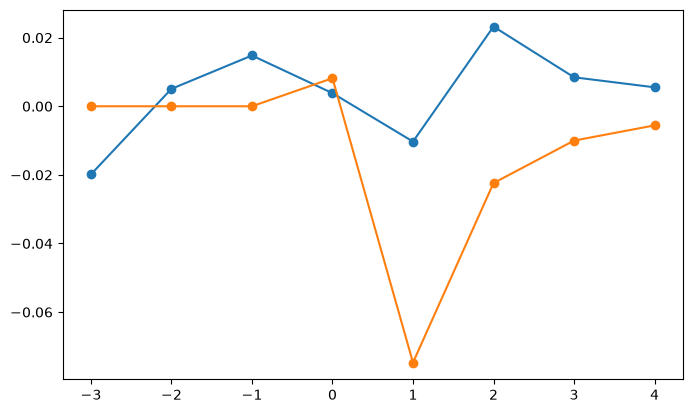

In [9]:
# Report the compact holdout-error summary.
display(holdout_diagnostic)

# Average observed and predicted residual paths across products.
# The averaged draw quantiles are descriptive rather than simultaneous intervals.
average_path = (
    product_holdout.groupby("relative_week", observed=True)
    .agg(
        observed_effect=("observed_effect", "mean"),
        predicted_effect=("predicted_effect", "mean"),
        predicted_q10=("predicted_q10", "mean"),
        predicted_q90=("predicted_q90", "mean"),
    )
    .reset_index()
)

if average_path.empty:
    raise RuntimeError("The average holdout event path could not be constructed.")

# Plot observed and predicted holdout paths on the same scale.
fig, ax = plt.subplots(figsize=(8, 4.8))

ax.plot(
    average_path["relative_week"],
    average_path["observed_effect"],
    marker="o",
    label="Observed holdout",
)

ax.plot(
    average_path["relative_week"],
    average_path["predicted_effect"],
    marker="o",
    label="Predicted",
)

In [10]:
# Add the central 80% predictive band implied by the calibrated draws.
ax.fill_between(
    average_path["relative_week"],
    average_path["predicted_q10"],
    average_path["predicted_q90"],
    alpha=0.20,
)

# Reference lines mark zero residual effect and the promotion week.
ax.axhline(0.0, linewidth=1.0)
ax.axvline(0.0, linestyle="--", linewidth=1.0)

ax.set_xlabel("Week relative to promotion")
ax.set_ylabel("Residual log-demand effect")
ax.set_title("Temporal holdout performance")
ax.legend()

fig.tight_layout()

# Save a publication-resolution copy before displaying the figure.
fig.savefig(
    HOLDOUT_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Supported-action figure

Text(0.5, 1.0, 'Product-specific supported promotion actions')

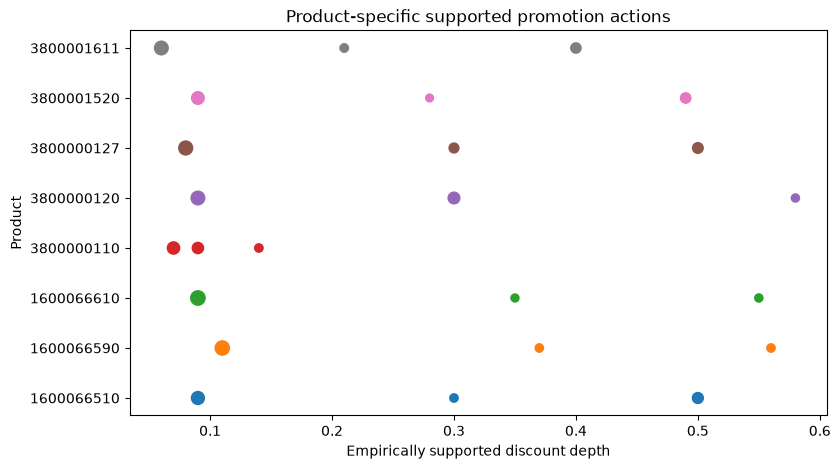

In [11]:
# Retain only positive promotion actions selected for the optimizer.
# Marker size scales with the square root of the empirical support count.
selected_support = support_table.loc[
    support_table["selected_for_grid"]
    & support_table["action"].gt(0)
].copy()

fig, ax = plt.subplots(figsize=(9, 5))

if selected_support.empty:
    print("No positive promotion depths met the empirical support thresholds.")
else:
    for product_name, group in selected_support.groupby(
        "product_name",
        observed=True,
    ):
        ax.scatter(
            group["action"],
            [product_name] * len(group),
            s=20 + 3 * np.sqrt(group["support_count"]),
        )

ax.set_xlabel("Empirically supported discount depth")
ax.set_ylabel("Product")
ax.set_title("Product-specific supported promotion actions")

In [12]:
# Finalize and export the supported-action figure.
fig.tight_layout()

fig.savefig(
    ACTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 6. Canonical calibration outputs

This section exports the product-specific behavioral draws, calibration summaries, supported action sets, and the support table used in the policy optimization. These objects define the feasible behavioral and action environment for all subsequent policy comparisons.

In [13]:
# Persist product-level behavioral draws and diagnostic tables for downstream use.
product_draws.to_pickle(PRODUCT_DRAW_PATH)
product_base_draws.to_pickle(PRODUCT_BASE_PATH)

product_summary.to_csv(PRODUCT_SUMMARY_PATH, index=False)
product_event_study.to_csv(PRODUCT_EVENT_PATH, index=False)
product_holdout.to_csv(PRODUCT_HOLDOUT_PATH, index=False)
product_holdout_summary.to_csv(PRODUCT_HOLDOUT_SUMMARY_PATH, index=False)
support_table.to_csv(PRODUCT_ACTION_SUPPORT_PATH, index=False)

# Bundle the exact supported actions with their labels and design metadata.
action_artifact = {
    "selected_products": selected_products,
    "product_names": product_names,
    "supported_action_sets": supported_action_sets,
    "support_table": support_table,
    "support_config": support_config,
}

pd.to_pickle(action_artifact, PRODUCT_ACTION_SET_PATH)

In [14]:
# Save a compact provenance artifact for the calibrated policy environment.
calibration_artifact = {
    "selected_products": selected_products,
    "product_names": product_names,
    "calibration_end_week": loaded["calibration_end_week"],
    "evaluation_start_week": loaded["evaluation_start_week"],
    "holdout_diagnostic": holdout_diagnostic,
    "supported_action_sets": supported_action_sets,
}

pd.to_pickle(
    calibration_artifact,
    PRODUCT_CALIBRATION_ARTIFACT_PATH,
)

print("Saved corrected product draws:", PRODUCT_DRAW_PATH)
print("Saved supported actions:", PRODUCT_ACTION_SET_PATH)

Saved corrected product draws: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\artifacts\calibration\product_behavioral_draws.pkl
Saved supported actions: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\artifacts\calibration\supported_actions.pkl
